In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA:

In [4]:

data.shape  # gives the number of rows and columns.

(1338, 7)

In [5]:
data.head      #gives top 5 values by default
data.head(2)   #gives specified number of values
data.tail      #gives 5 lower values by default
data.tail(7)   #gives specified number of lower values

,age,sex,bmi,children,smoker,region,charges
1331,23,female,33.40,0,no,southwest,10795.93733
1332,52,female,44.70,3,no,southwest,11411.68500
1333,50,male,30.97,3,no,northwest,10600.54830
1334,18,female,31.92,0,no,northeast,2205.98080
1335,18,female,36.85,0,no,southeast,1629.83350
1336,21,female,25.80,0,no,southwest,2007.94500
1337,61,female,29.07,0,yes,northwest,29141.36030


In [6]:
data.info()  # data.info and data.info() give different results

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
data.describe() # data.describe and data.describe() gives different results

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
data.isnull().sum() #indicates that no null value is present in the data

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

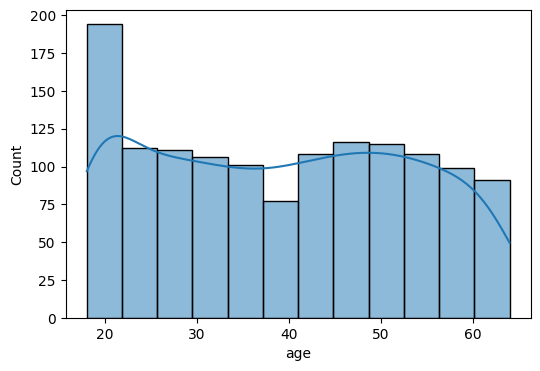

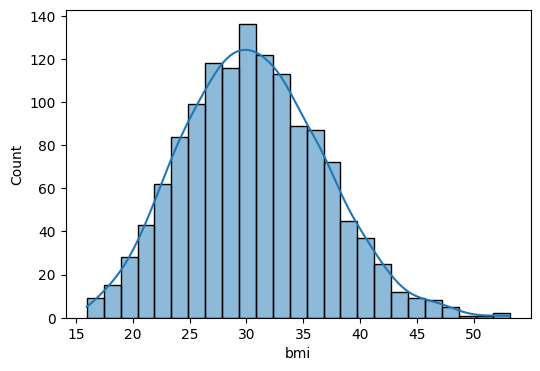

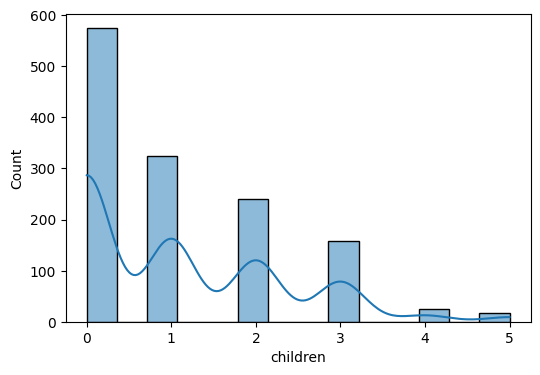

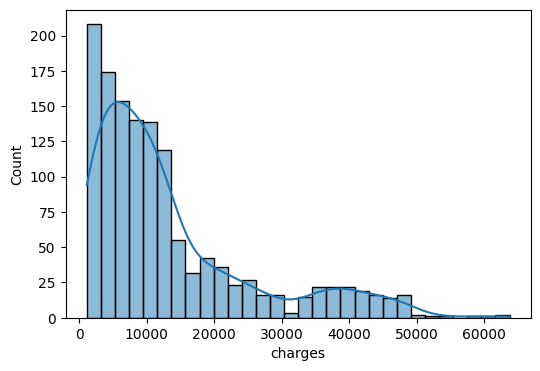

In [10]:
numeric_col=['age', 'bmi', 'children',  'charges']
for i in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data[i],kde=True)   #best way to check the distribution of the curve

<Axes: xlabel='children', ylabel='count'>

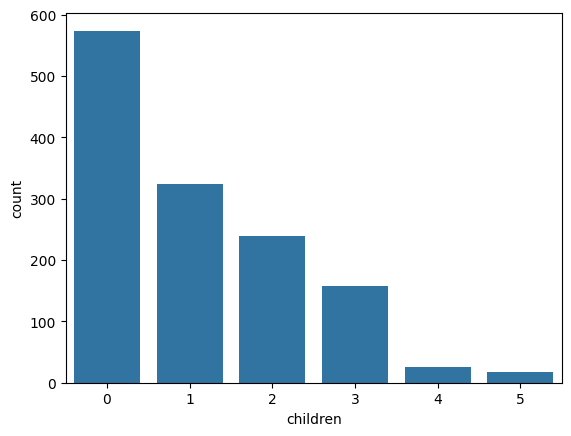

In [11]:
sns.countplot(x=data['children'])

<Axes: xlabel='count', ylabel='sex'>

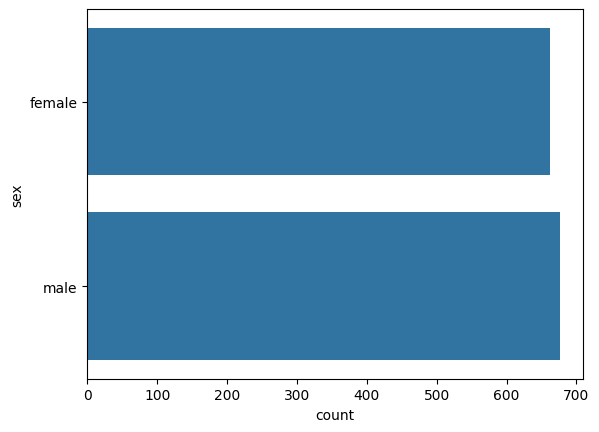

In [12]:
sns.countplot(y=data['sex'])

<Axes: xlabel='region', ylabel='count'>

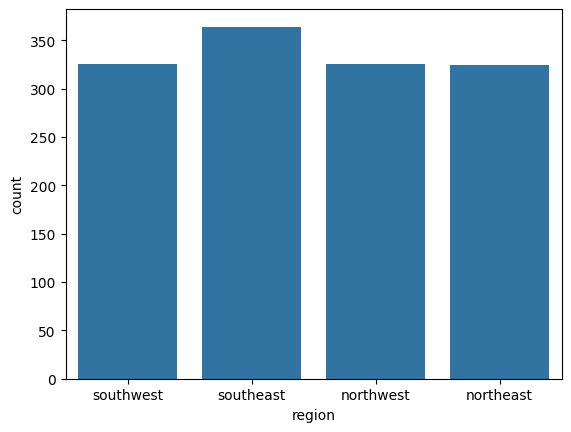

In [13]:
sns.countplot(x=data['region'])

<Axes: xlabel='smoker', ylabel='count'>

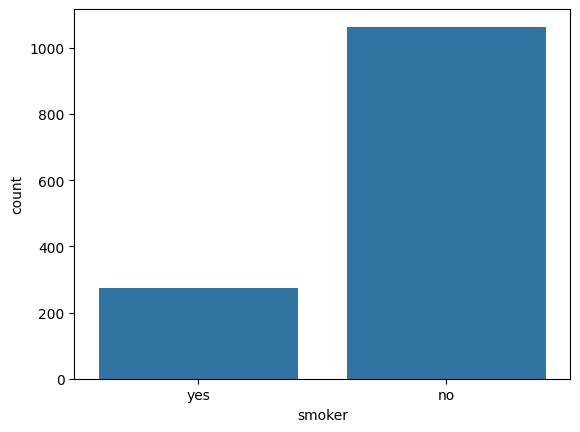

In [14]:
sns.countplot(x=data['smoker'])

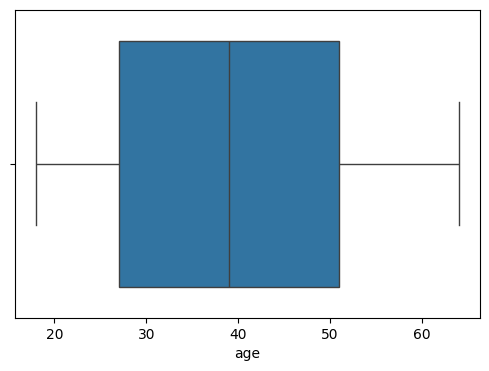

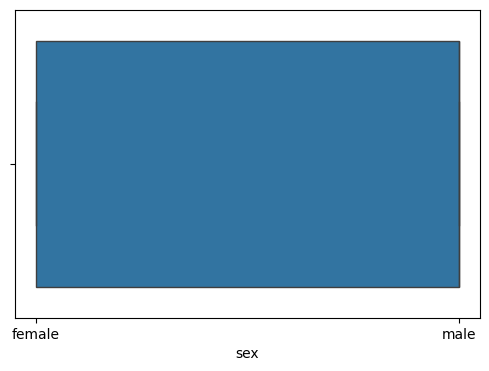

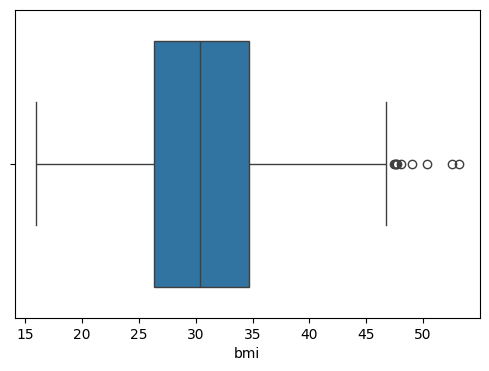

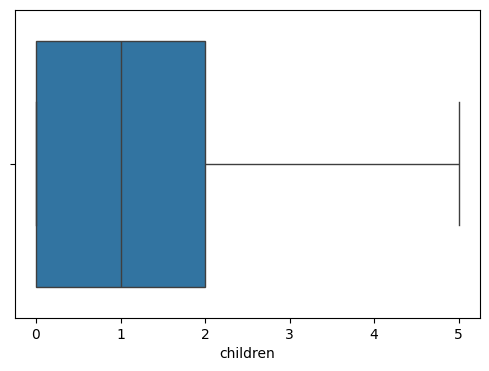

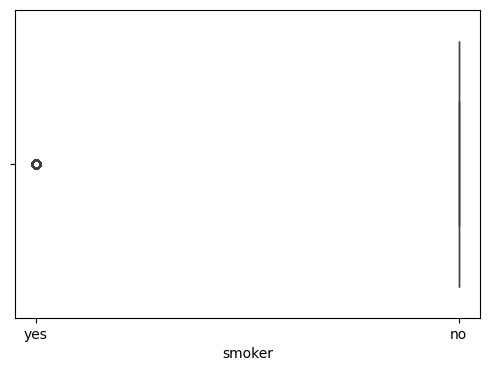

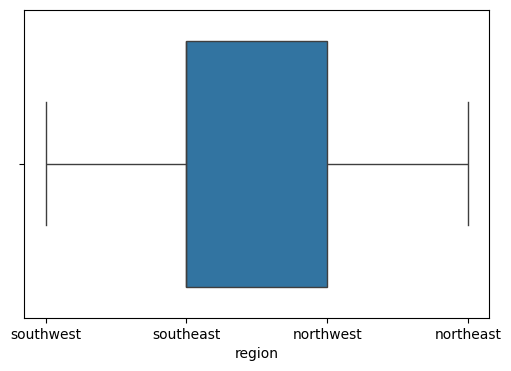

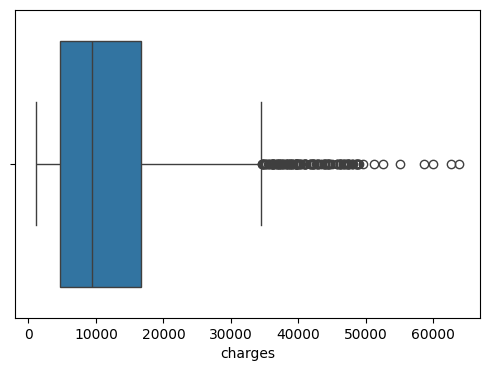

In [15]:
l=list(data.columns)
for i in l:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[i])

<Axes: >

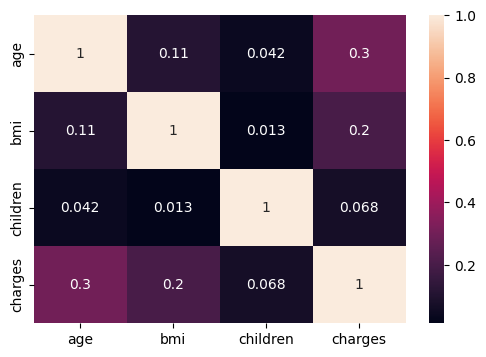

In [16]:
plt.figure(figsize=(6,4))
# representing correlation of the numeric columns
sns.heatmap(data.corr(numeric_only=True),annot=True)

# DATA CLEANING AND PREPROCESSING 

In [17]:
data_clean=data.copy()
data_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
data_clean.drop_duplicates(inplace=True)
data_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [19]:
data_clean.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [20]:
# encoding the object columns as machine knows 0 and 1 only
data_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [ ]:
#label encoding
data_clean['sex']=data_clean['sex'].map({'male':0,'female':1})
data_clean.head


<bound method NDFrame.head of       age  sex     bmi  children smoker     region      charges
0      19    1  27.900         0    yes  southwest  16884.92400
1      18    0  33.770         1     no  southeast   1725.55230
2      28    0  33.000         3     no  southeast   4449.46200
3      33    0  22.705         0     no  northwest  21984.47061
4      32    0  28.880         0     no  northwest   3866.85520
...   ...  ...     ...       ...    ...        ...          ...
1333   50    0  30.970         3     no  northwest  10600.54830
1334   18    1  31.920         0     no  northeast   2205.98080
1335   18    1  36.850         0     no  southeast   1629.83350
1336   21    1  25.800         0     no  southwest   2007.94500
1337   61    1  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 columns]>

In [22]:
data_clean['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [ ]:
#label encoding
data_clean['smoker']=data_clean['smoker'].map({'no':0,'yes':1})
data_clean

In [24]:
data_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [ ]:
# one hot encoding
data_clean=pd.get_dummies(data_clean,columns= ['region'],drop_first=True)
data_clean.head()

In [30]:
data_clean.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [43]:
data_clean=data_clean.astype(int)
data_clean.dtypes

age                   int64
sex                   int64
bmi                   int64
children              int64
smoker                int64
charges               int64
region_northeast      int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
bmi_cat_normal        int64
bmi_cat_overweight    int64
bmi_cat_obese         int64
dtype: object

# FEATURE ENGINEERING AND EXTRACTION 

<Axes: xlabel='bmi', ylabel='Count'>

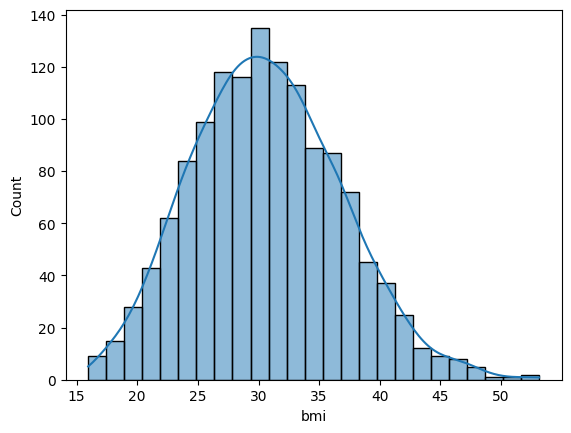

In [33]:
sns.histplot(data_clean['bmi'],kde=True)

In [35]:
data_clean['bmi_cat']=pd.cut(
    data_clean['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obese']

)
data_clean.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat
0,19,1,27.900,0,1,16884.92400,False,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,False,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,False,True,False,False,overweight


In [40]:
data_clean['bmi_cat'].value_counts()
data_clean = pd.get_dummies(data_clean, columns=['bmi_cat'], drop_first=True)
data_clean.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,19,1,27.900,0,1,16884.92400,False,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,False,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False,False,True,False


In [ ]:
data_clean=data_clean.astype(int)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,19,1,27,0,1,16884,0,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,1,0


In [48]:
pip install scikit-learn

     ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.9 MB 1.3 MB/s eta 0:00:07
     ---------------------------------------- 0.0/8.9 MB 487.6 kB/s eta 0:00:19
     ---------------------------------------- 0.1/8.9 MB 491.5 kB/s eta 0:00:18
      --------------------------------------- 0.1/8.9 MB 722.1 kB/s eta 0:00:13
     - -------------------------------------- 0.3/8.9 MB 1.1 MB/s eta 0:00:08
     - -------------------------------------- 0.3/8.9 MB 1.2 MB/s eta 0:00:08
     - -------------------------------------- 0.4/8.9 MB 1.3 MB/s eta 0:00:07
     -- ------------------------------------- 0.5/8.9 MB 1.5 MB/s eta 0:00:06
     -- ------------------------------------- 0.6/8.9 MB 1.5 MB/s eta 0:00:06
     -- ------------------------------------- 0.6/8.9 MB 1.4 MB/s eta 0:00:06
     --- ------------------------------------ 0.7/8.9 MB 1.5 MB/s eta 0:


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:

from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

data_clean[cols] = scaler.fit_transform(data_clean[cols])

In [50]:
data_clean.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_normal,bmi_cat_overweight,bmi_cat_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,1,0


In [57]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese'
]

correlations = {
    feature: pearsonr(data_clean[feature], data_clean['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,smoker,0.787234
0,age,0.298309
10,bmi_cat_obese,0.197660
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,sex,-0.058046
8,bmi_cat_normal,-0.105656


In [59]:
cat_features = [
    'sex', 'smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_cat_normal', 'bmi_cat_overweight', 'bmi_cat_obese'
]

In [60]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

data_clean['charges_bin'] = pd.qcut(data_clean['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(data_clean[col], data_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
sex,10.258784,0.01649,Reject Null (Keep Feature)
bmi_cat_obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_cat_normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_cat_overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [62]:
final_df = data_clean[['age', 'sex', 'bmi', 'children', 'smoker', 'charges','region_southeast','bmi_cat_obese']]

In [63]:
final_df

,age,sex,bmi,children,smoker,charges,region_southeast,bmi_cat_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
